In [14]:
import re
import json
import numpy as np
import matplotlib.pyplot as plt

from spacy.lang.de import German
import os
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go

In [2]:
#parties = ['CDU/CSU', 'SPD','GRÜNE', 'FDP', 'AfD', 'DIE LINKE', 'KPD', 'BP', 'DP', 'WAV', 'Z', 'fraktionslos' ]
parties = ['CDU/CSU', 'SPD','GRÜNE', 'FDP', 'AfD', 'DIE LINKE', 'fraktionslos']

## Load into Pandas Dataframe

In [26]:

relevant_protocols = os.listdir('./data/opendata_api/parsed_protocols/')
nlp = German()
nlp.add_pipe('sentencizer')
speech_id =0

comment_list = []
for protocol_filename in tqdm(relevant_protocols):
    with open('data/opendata_api/parsed_protocols/'+protocol_filename) as f:
        protocol = json.load(f)
        for speech in protocol:
            speech_id +=1
            speaker_name = speech['speaker']['name']
            speaker_party = speech['speaker']['party']
            doc = nlp(speech['text'])
            speech_len_sents = sum(1 for sent in doc.sents)
            if 'comments' in speech:
                for comment in speech['comments']:
                    comment_list.append([comment['text'],
                                  comment['commentator']['party'],
                                  comment['commentator']['name'],
                                  speaker_party,
                                  speaker_name,
                                  protocol_filename[7:-5],
                                  speech_len_sents, 
                                  speech_id
                                ])
columns=['comment_text', 'comment_party', 'comment_name',  'interrupted_speaker_party','interrupted_speaker', 'date', 'speech_len_sents', 'speech_id']
df_comments = pd.DataFrame(comment_list, columns = columns)



100%|██████████| 2065/2065 [12:34<00:00,  2.74it/s]


In [27]:
df_comments.head(-20)

,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
0,So kriegen Sie \ndie Steuerlüge nicht aus der ...,DIE LINKE,Dr. B riefs,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
1,Bravo!,SPD,<unknown>,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
2,Das ist doch die \nerste Lesung!,CDU/CSU,<unknown>,DIE LINKE,Dr. Barbara Höll,1991-03-12,11,2
3,Das ist eine \nFrechheit!,DIE LINKE,<unknown>,CDU/CSU,Dr. Jürgen Rüttgers,1991-03-12,15,3
4,Gebt erst \nmal das Vermögen der PDS dem Staat...,CDU/CSU,zu Bentrup,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
...,...,...,...,...,...,...,...,...
467898,Was ist jetzt hier \nder Unterschied zwischen ...,CDU/CSU,Markus Grübel,GRÜNE,Tobias B. Bacherle,2024-05-16,26,223492
467899,Es gilt das\nVölkerrecht!,CDU/CSU,<unknown>,GRÜNE,Tobias B. Bacherle,2024-05-16,26,223492
467900,Ach!,AfD,<unknown>,SPD,Emily Vontz,2024-05-16,33,223493
467901,Oijoijoi!,SPD,Brian Nickholz,CDU/CSU,Anne König,2024-05-16,30,223494


Leider sind noch Zeilenumbrüche enthalten...

In [28]:
df_comments['comment_text'] = df_comments['comment_text'].str.replace('\n', ' ')
df_comments['comment_name'] = df_comments['comment_name'].str.replace('\n', ' ')
df_comments['interrupted_speaker'] = df_comments['interrupted_speaker'].str.replace('\n', ' ')

Leider schreibt der Protokollant nicht immer einheitlich mit...

In [40]:
df_comments.loc[df_comments['comment_party'].isin(['CDU', 'CSU']), 'comment_party'] = 'CDU/CSU'

df_comments.loc[df_comments['interrupted_speaker_party'].isin(['CDU', 'CSU']), 'interrupted_speaker_party'] = 'CDU/CSU'

In [41]:
df_comments.to_csv('./data/comments.csv') # Abspeichern

# Wer ist am lautesten?

In [5]:
df_comments = pd.read_csv('./data/comments.csv')

In [8]:
def get_interruption_count_for_timespan(start_date, end_date):
    relevant_comments = df_comments[ (df_comments['date'] >=start_date) & (df_comments['date']  <= end_date)]
    
    custom_order = parties

    num_interruptions = relevant_comments.groupby('comment_party').size().reset_index(name='num_of_interruptions')

    # Set the index to 'comment_party' and reorder the rows
    num_interruptions = num_interruptions.set_index('comment_party').reindex(custom_order)

    return num_interruptions

In [15]:
start_date, end_date = '2021-09-14', '2024-05-24'
df_interruptions_num = get_interruption_count_for_timespan(start_date, end_date)
df_interruptions_num

,num_of_interruptions
comment_party,
CDU/CSU,24241
SPD,10112
GRÜNE,11392
FDP,5883
AfD,16713
DIE LINKE,2831
fraktionslos,29


In [136]:

def plot_interruption_numbers_per_party(df_interruptions_num, norm=False):
    # Extract party names and interruption counts
    parties = df_interruptions_num.index
    comments_per_party = df_interruptions_num['num_of_interruptions']

    # Define colors for each party
    party_colors = {
        'CDU/CSU': 'black',
        'SPD': 'red',
        'GRÜNE': 'green',
        'FDP': 'yellow',
        'AfD': 'blue',
        'DIE LINKE': 'red',
        'fraktionslos': 'gray'
    }

    # Create a bar chart with default color for each party
    fig = go.Figure(data=[go.Bar(x=parties, y=comments_per_party, marker_color=[party_colors[party] for party in parties])])


    yaxis = dict(autorange=True)
    title = 'Number of Interruptions by Party'
    if not norm:
        yaxis['title'] = 'Number of Interruptions'
    else:
        title = 'Number of Interruptions normalized by Party Seats'

    fig.update_layout(title=title,
                      xaxis_title="Party",
                      xaxis=dict(tickangle=-45),
                      yaxis=yaxis
                      )

    # Show the figure
    fig.show()
plot_interruption_numbers_per_party(df_interruptions_num)

Im 20. Bundestag gab es zum Zeitpunkt dieser Daten 170 Sitzungen.  
    - Das macht für z.B. die Union 24241/170 = 142 Unterbrechungen/Sitzung.  
    - Bei der AfD sind es 16713/170 = 98 Unterbrechungen/Sitzung.   
Wir finden, das ist schon ziemlich viel.

Absolute Zahlen sind zwar schön, erzählen aber nicht die ganze Geschichte. In der Linken Fraktion sitzen ja deutlich weniger Abgeordnete, als in der Union.

In [135]:
vote_percentages = [0.241, 0.257, 0.148, 0.115, 0.103, 0.049] # in correct order for this NB, 20. BT
abgeordnete_absolute_nums =  [percentage * 733 for percentage in vote_percentages] # Seats in the 20th BT
df_interruptions_num_norm_seats = df_interruptions_num.drop(index='fraktionslos').div(abgeordnete_absolute_nums, axis=0)
df_interruptions_num_norm_seats['num_of_interruptions'] = df_interruptions_num_norm_seats['num_of_interruptions'].round(2)
plot_interruption_numbers_per_party(df_interruptions_num_norm_seats, norm=True)

Hier sind zwar die Zahlen nicht mehr direkt interpretierbar, aber die Relationen der Säulenhöhen sprechen für sich.  
War DIE LINKE im Plot davor mit fast der Hälfte der absoluten Unterbrechungen weit hinter der FDP, so sieht man, dass die linken abgeordneten doch ein Stück öfter hineinreden, als deren Kollegen der FDP.




# Wer ruft wem überhaupt rein?

In [91]:
def get_interrupt_matrix_for_timespan(start_date, end_date):
    relevant_comments = df_comments[ (df_comments['date'] >=start_date) & (df_comments['date']  <= end_date)]

    df_unique_speeches = relevant_comments.drop_duplicates(subset=['interrupted_speaker_party', 'speech_id'])
    df_sum_speech_len_sents = df_unique_speeches.groupby('interrupted_speaker_party')['speech_len_sents'].sum().reset_index()
    df_sum_speech_len_sents.columns = ['Party', 'Total_Speech_Length_Sents']
    df_sum_speech_len_sents = df_sum_speech_len_sents.set_index('Party').reindex(parties)

    interruption_matrix = pd.crosstab(relevant_comments['comment_party'], relevant_comments['interrupted_speaker_party']) # pretty handy function...

    interruption_matrix = interruption_matrix.reindex(parties, axis=1)
    interruption_matrix = interruption_matrix.reindex(parties, axis=0)

    return interruption_matrix.T, df_sum_speech_len_sents

start_date, end_date = '1991-03-14', '2024-05-24'
start_date, end_date = '2021-09-14', '2024-05-24'
interruption_matrix, sentence_counts = get_interrupt_matrix_for_timespan(start_date, end_date)
#interruption_matrix
sentence_counts

,Total_Speech_Length_Sents
Party,
CDU/CSU,172641
SPD,161533
GRÜNE,96928
FDP,77129
AfD,77301
DIE LINKE,37700
fraktionslos,5940


In [92]:
interruption_matrix

comment_party,CDU/CSU,SPD,GRÜNE,FDP,AfD,DIE LINKE,fraktionslos
interrupted_speaker_party,,,,,,,
CDU/CSU,2933,5092,6295,3057,2623,720,1
SPD,8892,862,573,424,5874,495,5
GRÜNE,6105,320,546,236,3946,296,7
FDP,4373,341,367,442,2276,468,2
AfD,864,2900,2977,1001,920,457,3
DIE LINKE,945,412,435,633,994,380,0
fraktionslos,129,185,199,90,80,15,11


Normalize with sentences spoken by speaker party

In [93]:
interruption_matrix_norm_sents = interruption_matrix.div(np.array(sentence_counts))
interruption_matrix_norm_sents

comment_party,CDU/CSU,SPD,GRÜNE,FDP,AfD,DIE LINKE,fraktionslos
interrupted_speaker_party,,,,,,,
CDU/CSU,0.016989,0.029495,0.036463,0.017707,0.015193,0.004171,0.000006
SPD,0.055048,0.005336,0.003547,0.002625,0.036364,0.003064,0.000031
GRÜNE,0.062985,0.003301,0.005633,0.002435,0.040711,0.003054,0.000072
FDP,0.056697,0.004421,0.004758,0.005731,0.029509,0.006068,0.000026
AfD,0.011177,0.037516,0.038512,0.012949,0.011902,0.005912,0.000039
DIE LINKE,0.025066,0.010928,0.011538,0.016790,0.026366,0.010080,0.000000
fraktionslos,0.021717,0.031145,0.033502,0.015152,0.013468,0.002525,0.001852


This is still not showing the whole picture. After all, there are more than double of people in the CDU/CSU-Fraktion than in the AfD Fraktion  
So let's normalize by number of seats. The percentages of second votes can be found [here](https://www.bundestag.de/parlament/wahlen/ergebnisse_seit1949-244692)
Normalizing by number of seats means dividing the columns! by the vote percentage -> lower vote-percentage -> score gets higher.  
Sadly we lose some interpretability because it's not plain interruptions/sentence anymore and the resulting unit (interruptions/sentence)/speaker_percentage is a bit weird.  
Also for simplicity's sake let's drop fraktionslos. Their numbers are not too interesting and calculating the next parts would be unnecessarily hard.

In [94]:
vote_percentages = [0.241, 0.257, 0.148, 0.115, 0.103, 0.049] # in correct order for this NB, 20. BT
interruption_matrix_norm_sents = interruption_matrix_norm_sents.drop(labels='fraktionslos')
interruption_matrix_norm_sents = interruption_matrix_norm_sents.drop(columns='fraktionslos')

interruption_matrix_norm_sents_seats = interruption_matrix_norm_sents.div(vote_percentages, axis=1)
interruption_matrix_norm_sents_seats

comment_party,CDU/CSU,SPD,GRÜNE,FDP,AfD,DIE LINKE
interrupted_speaker_party,,,,,,
CDU/CSU,0.070494,0.114765,0.246371,0.153976,0.147509,0.085112
SPD,0.228413,0.020764,0.023968,0.022825,0.353049,0.062539
GRÜNE,0.261348,0.012846,0.038061,0.021172,0.395249,0.062323
FDP,0.235258,0.017203,0.032150,0.049832,0.286495,0.123832
AfD,0.046378,0.145975,0.260215,0.112603,0.115549,0.120652
DIE LINKE,0.104010,0.042523,0.077963,0.146004,0.255981,0.205706


Jetzt, da die Werte vergleichbar sind, haben sie auch einen schönen Plot verdient

In [103]:

def plot_relevant_parties(comment_matrix):
    plt.figure(figsize=(7,7))
    sns.set_style("whitegrid")

    ax = sns.heatmap(comment_matrix, cmap="Blues", annot=False, cbar=True, square=True, cbar_kws={'shrink': 0.8})

    # Rotate x-axis labels
    ax.set_xticklabels(parties[:-1], rotation=20)

    # Set y-axis labels to the top
    ax.xaxis.set_ticks_position('top')

    # Rotate x-axis labels
    ax.set_yticklabels(parties[:-1], rotation=0)
    
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('Interruptor Party', labelpad=5)
    ax.set_ylabel('Speaker Party', labelpad=5)

    plt.title('Interruptions in the German Bundestag', pad=20)
    plt.show()


In [106]:
interruption_matrix_norm_seats = interruption_matrix.drop(columns='fraktionslos').drop(index='fraktionslos').div(vote_percentages, axis=1)

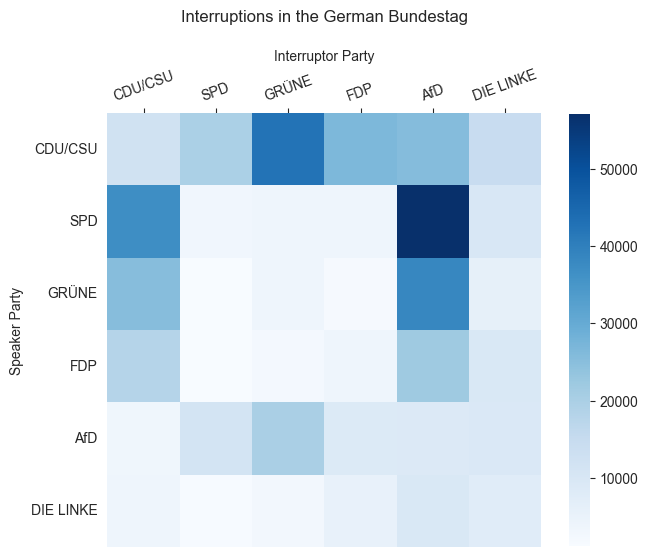

In [107]:
plot_relevant_parties(interruption_matrix_norm_seats)

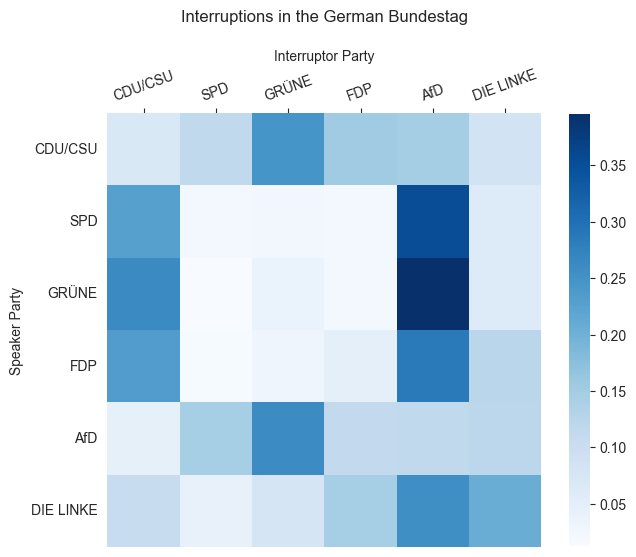

In [104]:
plot_relevant_parties(interruption_matrix_norm_sents_seats)

Interessanter Plot, oder?  

Das allererste, was einem ins Auge springt, ist, dass die AfD doch wie - zumindest von uns - erwartet ziemlich viele Unterbrechungen (pro gesprochenem Satz der anderen und pro eigenem Sitz)

# DIVIDER

In [13]:
comment_matrix_normalized_sents_seats = comment_matrix_normalized_sents.copy()

for party in parties[:6]:
    comment_matrix_normalized_sents_seats[party_indices[party],:] /= vote_percentages[party_indices[party]]/100

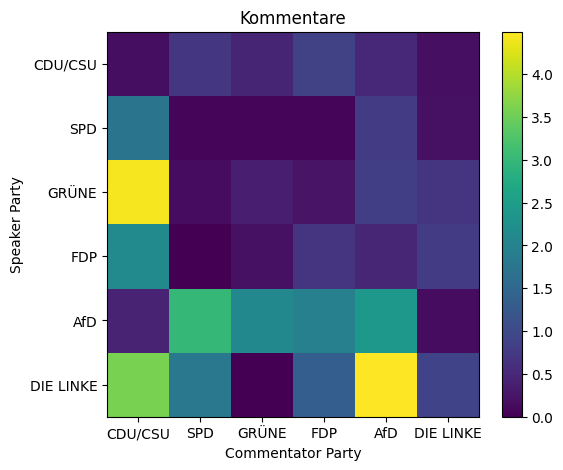

In [14]:
# now normalized + focus only on relevant parties
plt.figure(figsize=(6, 5))
plt.imshow(comment_matrix_normalized_sents_seats[:6,:6], cmap='viridis', aspect='auto')

# labels
plt.xticks(ticks=np.arange(6), labels=parties[:6])
plt.yticks(ticks=np.arange(6), labels=parties[:6])
plt.colorbar()
plt.xlabel('Commentator Party')
plt.ylabel('Speaker Party')
plt.title('Kommentare')

plt.show()

# Let's look at different Bundestage

In [47]:
interruption_matrix

interrupted_speaker_party,AfD,CDU/CSU,DIE LINKE,FDP,GRÜNE,SPD,fraktionslos,Total
comment_party,,,,,,,,
AfD,1590,7574,2557,3409,5779,9654,101,30664
CDU/CSU,3600,23350,14950,12456,29008,50619,629,134612
DIE LINKE,3019,18156,2780,4419,2761,7140,70,38345
FDP,2104,17495,5802,6599,11770,26171,303,70244
GRÜNE,6683,40301,2988,8796,3544,11674,380,74366
SPD,6900,58199,5887,24692,7899,15475,559,119611
fraktionslos,3,10,1,9,11,21,26,81
Total,23899,165085,34965,60380,60772,120754,2068,467923


In [15]:
def get_comment_matrix_for_protocol(protocol_filename):
    with open('data/opendata_api/parsed_protocols/'+protocol_filename) as f:
        protocol = json.load(f)
    party_indices = {party: i for i, party in enumerate(parties)}

    aggregated_matrix = np.zeros([len(parties), len(parties)], dtype= int)
    num_sents = np.zeros(len(parties), dtype = int)
    nlp = German()
    nlp.add_pipe('sentencizer')
    
    for speech in protocol:
        party_speaker = speech['speaker']['party']
        speaker_party_index = party_indices[party_speaker]
        for comment in speech['comments']:
            comment_party = comment['commentator']['party']
            if comment_party== 'CDU' or comment_party=='CSU':
                comment_party = 'CDU/CSU'
            aggregated_matrix[speaker_party_index][party_indices[comment_party]] += 1
        
        # get total number of sents
        party_speaker = speech['speaker']['party']
        doc = nlp(speech['text'])
        num_sents[party_indices[party_speaker]] +=  sum(1 for sent in doc.sents)
        
    return aggregated_matrix, num_sents

In [16]:
def get_comment_matrix_timespan(start_date, end_date):
    out_comment_matrix = np.zeros([len(parties), len(parties)], dtype = int)
    out_sent_counts = np.zeros(len(parties), dtype = int)
    relevant_protocols = [protocol_filename for protocol_filename in os.listdir('./data/opendata_api/parsed_protocols/') if protocol_filename[7:-5] >start_date and protocol_filename[7:-5] <end_date]
    for protocol_filename in tqdm(relevant_protocols):
        mat1, sent_counts= get_comment_matrix_for_protocol(protocol_filename)
        out_comment_matrix += mat1
        out_sent_counts += sent_counts
    return out_comment_matrix, out_sent_counts

In [17]:
comment_matrix_20, sent_counts_20 = get_comment_matrix_timespan('2021-10-26', '2024-05-21') # current BT

100%|██████████| 169/169 [02:07<00:00,  1.32it/s]


Let's take a look

In [19]:
comments_by_party_20 = np.sum(comment_matrix_20, axis = 0)

In [103]:
import plotly.graph_objects as go
def plot_per_party_col(comments_per_party, norm = False):
    # Create a bar chart
    fig = go.Figure(data=[go.Bar(x=parties, y=comments_per_party)])

    # Update layout for better visualization
    yaxis = dict(autorange=True)
    title = 'Number of Comments normalized by Party Seats'
    if not norm:
       yaxis['title'] = 'Number of Comments'
       title = 'Number of Comments by Party'

    fig.update_layout(title=title,
                    xaxis_title="Party",
                    xaxis=dict(tickangle=-45),
                    yaxis=yaxis
                    )

    # Show the figure
    fig.show()
plot_per_party_col(comments_by_party_20)

Let's normalize this by the percentage of seats in the BT  
We dropped "fraktionslos" as they are so few, the data is not meaningful  
(Also: keep in mind the numbers are not "real" comments anymore)

In [104]:
comments_by_party_20_seat_norm = comments_by_party_20[:6]/vote_percentages
plot_per_party_col(comments_by_party_20_seat_norm, norm=True)

In [22]:
def normalize_comment_matrix(comment_matrix, norm_vector, seats = False, bt_period = 20):
    
    out_mat = np.array(comment_matrix, dtype = float)
    for i in range(len(parties)):
        out_mat[i,:] /= norm_vector[i]+1 #smoothing for 0 values

    if seats:
        if bt_period == 20:
            second_votes= [0.241, 0.257, 0.148, 0.115, 0.103, 0.049] # in correct order for this NB
        elif bt_period == 19:
            second_votes = [0.329, 0.205, 0.089, 0.107, 0.092, 0.126]
        elif bt_period == 18:
            second_votes = [0.415, 0.257, 0.084, 0.048, 0.086, 0.047 ]
        else:
            KeyError('Invalid BT-Period')
        for party in parties[:6]:
            out_mat[:,party_indices[party]] /= vote_percentages[party_indices[party]]
    return out_mat

In [23]:
comment_matrix_sent_norm_20 = normalize_comment_matrix(comment_matrix_20, sent_counts_20, seats=False)

In [24]:
comment_matrix_sent_seats_norm_20 = normalize_comment_matrix(comment_matrix_20, sent_counts_20, seats=True)

In [88]:
import seaborn as sns
def plot_relevant_parties(comment_matrix):
    plt.figure(figsize=(7,7))
    sns.set_style("whitegrid")

    ax = sns.heatmap(comment_matrix, cmap="Blues", annot=False, cbar=True, square=True, cbar_kws={'shrink': 0.8})

    # Rotate x-axis labels
    ax.set_xticklabels(parties, rotation=20)

    # Set y-axis labels to the top
    ax.xaxis.set_ticks_position('top')

    # Rotate x-axis labels
    ax.set_yticklabels(parties, rotation=0)
    
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('Interruptor Party', labelpad=5)
    ax.set_ylabel('Speaker Party', labelpad=5)

    plt.title('Interruptions in the German Bundestag', pad=20)
    plt.show()


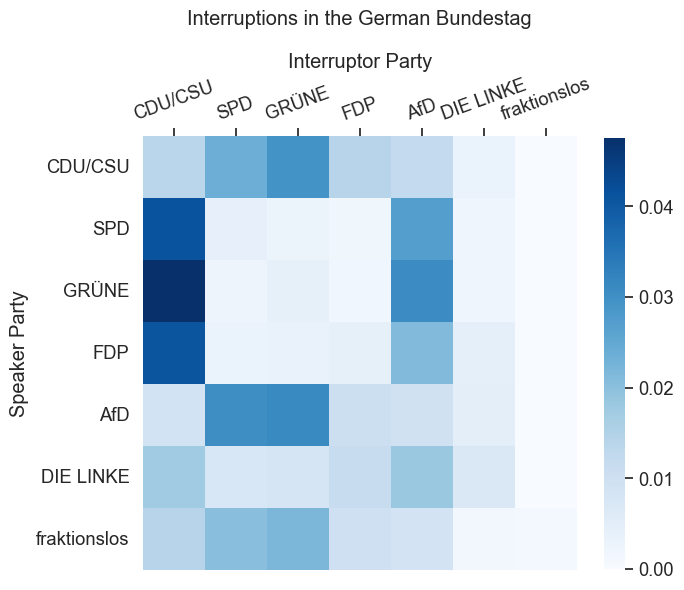

In [89]:
cmsn20 = comment_matrix_sent_norm_20

plot_relevant_parties(comment_matrix_sent_norm_20)

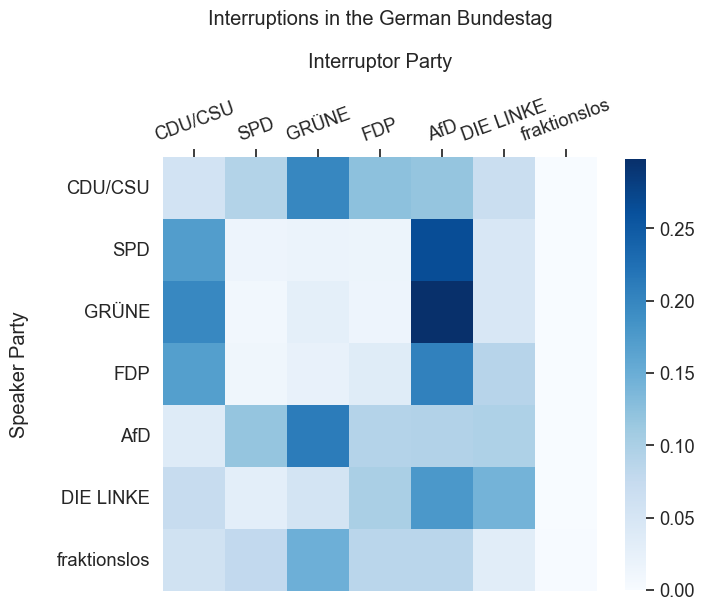

In [82]:
plot_relevant_parties(comment_matrix_sent_seats_norm_20)

In [197]:
comment_matrix_19, sent_counts_19 = get_comment_matrix_timespan('2017-10-26', '2021-10-26') # last BT

100%|██████████| 238/238 [02:42<00:00,  1.46it/s]


In [226]:
comment_matrix_sent_norm_19 = normalize_comment_matrix(comment_matrix_19, sent_counts_19)

In [224]:
comment_matrix_sent_seats_norm_19 = normalize_comment_matrix(comment_matrix_19, sent_counts_19, seats=True, bt_period=19)

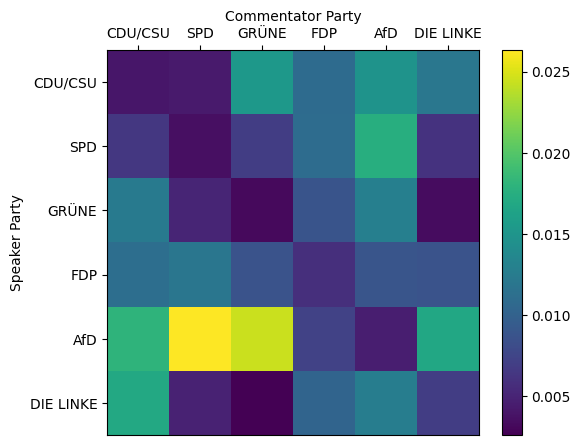

In [227]:
plot_relevant_parties(comment_matrix_sent_norm_19)

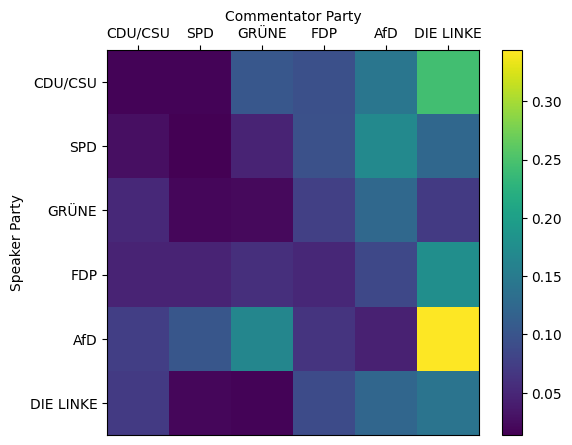

In [225]:
plot_relevant_parties(comment_matrix_sent_seats_norm_19)

In [239]:
comment_matrix_18, sent_counts_18 = get_comment_matrix_timespan('2013-10-22', '2017-09-05') # second to last BT

100%|██████████| 243/243 [01:43<00:00,  2.34it/s]


In [249]:
comment_matrix_sent_norm_18 = normalize_comment_matrix(comment_matrix_18, sent_counts_18)
comment_matrix_sent_norm_18[party_indices['FDP']] = np.zeros(len(parties), dtype = float) # throw irrelevant data away
# expl.: Cornelia Pieper FDP is minister at the start of this BT Period but FDP is not in the BT. -> due to low speech time -> high normalized output
# she also occurs in only one protocol of this period

In [250]:
comment_matrix_sent_seats_norm_18 = normalize_comment_matrix(comment_matrix_18, sent_counts_18, seats=True, bt_period=18)
comment_matrix_sent_seats_norm_18[party_indices['FDP']] = np.zeros(len(parties), dtype = float)

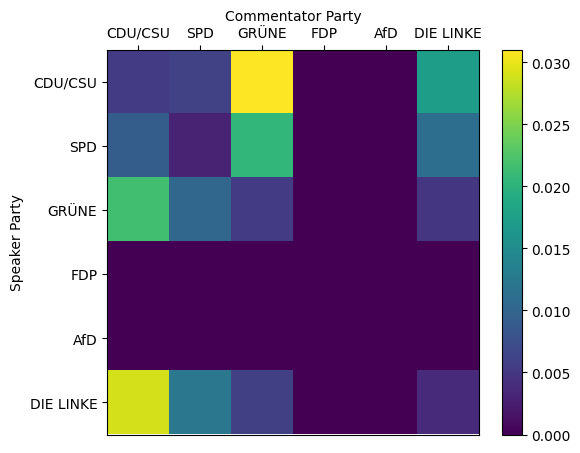

In [251]:
plot_relevant_parties(comment_matrix_sent_norm_18)

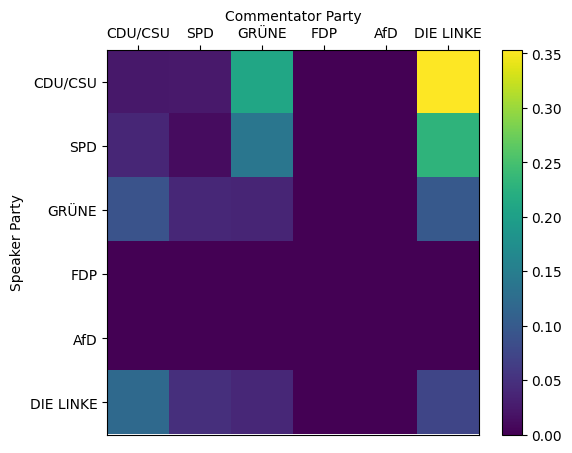

In [252]:
plot_relevant_parties(comment_matrix_sent_seats_norm_18)

In [248]:
start_date, end_date = '2013-10-22', '2017-09-05'
relevant_protocols = [protocol_filename for protocol_filename in os.listdir('./data/parsed_protocols/') if protocol_filename[7:-5] >start_date and protocol_filename[7:-5] <end_date]
for protocol_filename in relevant_protocols:
    with open('data/parsed_protocols/'+protocol_filename) as f:
        protocol = json.load(f)
    party_indices = {party: i for i, party in enumerate(parties)}
    for speech in protocol:
        if speech['speaker']['party'] == "FDP":
            print(f"fdp found in {protocol_filename}, speaker: {speech['speaker']}")
        for comment in speech['comments']:
            if comment['commentator']['party'] == "FDP":
                print(f"fdp found in {protocol_filename}, speaker: {speech['speaker']}")

fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found in 18_003_2013-11-28.json, speaker: {'name': 'Cornelia Pieper', 'party': 'FDP'}
fdp found 